# 项目 7：客户流失预测中的特征工程

**项目目标：** 展示特征工程如何提升客户流失预测模型的效果。我们会先用清洗后的原始特征建立基线模型，再构造更能表达客户行为的新特征，并比较模型表现。

### 本项目将覆盖的核心概念

1. **特征工程：** 把原始字段转换成更有预测价值、也更容易解释的变量。
2. **数据清洗：** 处理被错误存成文本的数值列，并准备目标标签。
3. **基线模型：** 在加入新特征前建立一个公平的比较基准。
4. **特征构造：** 包括 tenure 分箱、服务类别简化、附加服务数量统计、费用比例特征等。
5. **Pipeline 建模：** 使用 `ColumnTransformer` 和 `Pipeline` 统一处理数值特征与类别特征。
6. **模型对比：** 比较 Accuracy 和流失客户类别的 F1-score。
7. **特征选择：** 测试保留一部分重要特征是否能简化或提升模型。

### 理论概念：什么是特征工程？

特征工程是指利用业务理解和数据规律，从原始数据中创造新的输入变量，让机器学习模型更容易学习到关键模式。

在客户流失预测中，原始字段如 `tenure`、`MonthlyCharges` 和各类服务订阅状态本身有价值，但它们不一定直接表达客户行为。比如：

- `tenure_group` 可以把客户生命周期分组；
- `num_add_services` 可以表示客户使用了多少附加服务；
- `monthly_charge_ratio` 可以表示客户每月费用相对留存时间是否偏高。

好的特征工程可以：

- 显式暴露隐藏模式；
- 提升模型预测性能；
- 增强模型解释性；
- 把业务知识注入数据集。

本项目会通过“基线模型 vs. 加入特征工程后的模型”来验证它的作用。

### 第 1 步：准备环境 - 导入库并加载数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set plot style
sns.set_style('whitegrid')

In [8]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"

Cloning into 'Datasets'...
fatal: unable to access 'https://github.com/HarshvardhanSingh-13/Datasets/': Failed to connect to github.com port 443 via 127.0.0.1 after 2057 ms: Could not connect to server


In [10]:
# Load the dataset from the user-provided file
df = pd.read_csv('../Datasets/Customer Churn Dataset/Telco-Customer-Churn.csv')

print("Dataset loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Dataset loaded successfully.
Data shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 第 2 步：数据清洗与初始准备

真实业务数据通常并不干净。建模前，我们需要检查数据类型、缺失值和需要转换的字段。

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**发现的关键问题：** `TotalCharges` 理论上应该是数值列，但当前是 `object` 类型。这通常说明列中存在空字符串或无法直接转成数字的内容。因此需要先转成数值，再处理缺失值。

In [12]:
print(f"Shape before cleaning: {df.shape}")

# Convert TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Shape after converting TotalCharges to numeric: {df.shape}")


# Find how many rows have missing TotalCharges
print(f"Number of missing TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Impute the missing values with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(f"Shape after imputing TotalCharges: {df.shape}")


# Convert target variable 'Churn' to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"Shape after converting Churn to binary: {df.shape}")


# Drop rows with missing Churn values
df.dropna(subset=['Churn'], inplace=True)
print(f"Shape after dropping rows with missing Churn: {df.shape}")


# Drop customerID as it's not a predictive feature
# df.drop('customerID', axis=1, inplace=True) # This line is commented out as customerID is already dropped

print("\nData cleaning complete.")

Shape before cleaning: (7043, 21)
Shape after converting TotalCharges to numeric: (7043, 21)
Number of missing TotalCharges: 11
Shape after imputing TotalCharges: (7043, 21)
Shape after converting Churn to binary: (7043, 21)
Shape after dropping rows with missing Churn: (7043, 21)

Data cleaning complete.


In [13]:
pd.set_option('display.max_columns', None)
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [14]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 第 3 步：模型 1 - 不使用特征工程的基线表现

基线模型只使用清洗后的原始字段。它的作用是提供一个比较基准：后续特征工程是否有效，必须和这个基线结果对比，而不是只看单个模型分数。

In [15]:
# Define features (X) and target (y)
X_base = df.drop('Churn', axis=1)
y_base = df['Churn']

# Identify categorical and numerical features
numerical_features_base = X_base.select_dtypes(include=np.number).columns.tolist()
categorical_features_base = X_base.select_dtypes(include=['object']).columns.tolist()

# Create the preprocessing pipeline
preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_base),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_base)])

# Split data
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2, random_state=42, stratify=y_base)

# Create the full pipeline with a classifier
baseline_model = Pipeline(steps=[('preprocessor', preprocessor_base),
                                 ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

# Train and evaluate the baseline model
baseline_model.fit(X_train_base, y_train_base)
y_pred_base = baseline_model.predict(X_test_base)

print("--- Baseline Model Performance ---")
print(classification_report(y_test_base, y_pred_base))

--- Baseline Model Performance ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### 第 4 步：核心任务 - 特征工程

现在我们创建一个增强版数据集。目标不是随便增加列，而是构造更能表达客户行为和业务逻辑的特征。

In [22]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [23]:
df_eng = df.copy()

# 1. Binning 'tenure'
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-1 Year', '1-2 Years', '2-4 Years', '4-5 Years', '5+ Years']
df_eng['tenure_group'] = pd.cut(df_eng['tenure'], bins=bins, labels=labels, right=False)

# 2. Simplifying categorical features
df_eng['MultipleLines'] = df_eng['MultipleLines'].replace({'No phone service': 'No'})
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df_eng[col] = df_eng[col].replace({'No internet service': 'No'})

# 3. Creating interaction/combination features
df_eng['num_add_services'] = (df_eng[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']] == 'Yes').sum(axis=1)

# 4. Create a feature for monthly charge to tenure ratio
df_eng['monthly_charge_ratio'] = df_eng['MonthlyCharges'] / (df_eng['tenure'] + 1) # +1 to avoid division by zero

print("Feature engineering complete. New features added.")
df_eng.head()

Feature engineering complete. New features added.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_add_services,monthly_charge_ratio
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4 Years,2,1.627143
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,2,17.950000
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,3,0.919565
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,23.566667


`monthly_charge_ratio` 的计算公式是：

```text
monthly_charge_ratio = MonthlyCharges / (tenure + 1)
```

这里给 `tenure` 加 1，是为了避免 `tenure = 0` 时除以 0。这个特征可以帮助模型识别“客户留存时间不长，但月费用较高”的情况，这类客户可能更容易流失。

### 第 5 步：模型 2 - 使用特征工程后的模型表现

接下来使用增强后的数据集训练同一种模型。保持分类器一致，是为了让对比更公平：如果性能变化，更可能是特征变化带来的。

In [24]:
# Drop original tenure as we have a binned version now
df_eng.drop('tenure', axis=1, inplace=True)

# Define features (X) and target (y) for the engineered dataset
X_eng = df_eng.drop('Churn', axis=1)
y_eng = df_eng['Churn']

# Identify new feature types
numerical_features_eng = X_eng.select_dtypes(include=np.number).columns.tolist()
# Note: 'tenure_group' is now a categorical feature
categorical_features_eng = X_eng.select_dtypes(include=['object', 'category']).columns.tolist()

# Create the new preprocessing pipeline
preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_eng),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_eng)])

# Split data
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng)

# Create the full pipeline with the same classifier for a fair comparison
enhanced_model = Pipeline(steps=[('preprocessor', preprocessor_eng),
                                 ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

# Train and evaluate the enhanced model
enhanced_model.fit(X_train_eng, y_train_eng)
y_pred_eng = enhanced_model.predict(X_test_eng)

print("--- Enhanced Model Performance (with Feature Engineering) ---")
print(classification_report(y_test_eng, y_pred_eng))

--- Enhanced Model Performance (with Feature Engineering) ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



### 第 6 步：模型比较与初步结论

**性能对比：** 这里重点看正类 `Churn = 1` 的 F1-score，因为流失客户通常是少数类，也是业务上最想提前识别的人群。

如果增强模型提升了流失类的 F1-score，说明新特征帮助模型更好地识别有流失风险的客户，同时兼顾了 precision 和 recall。

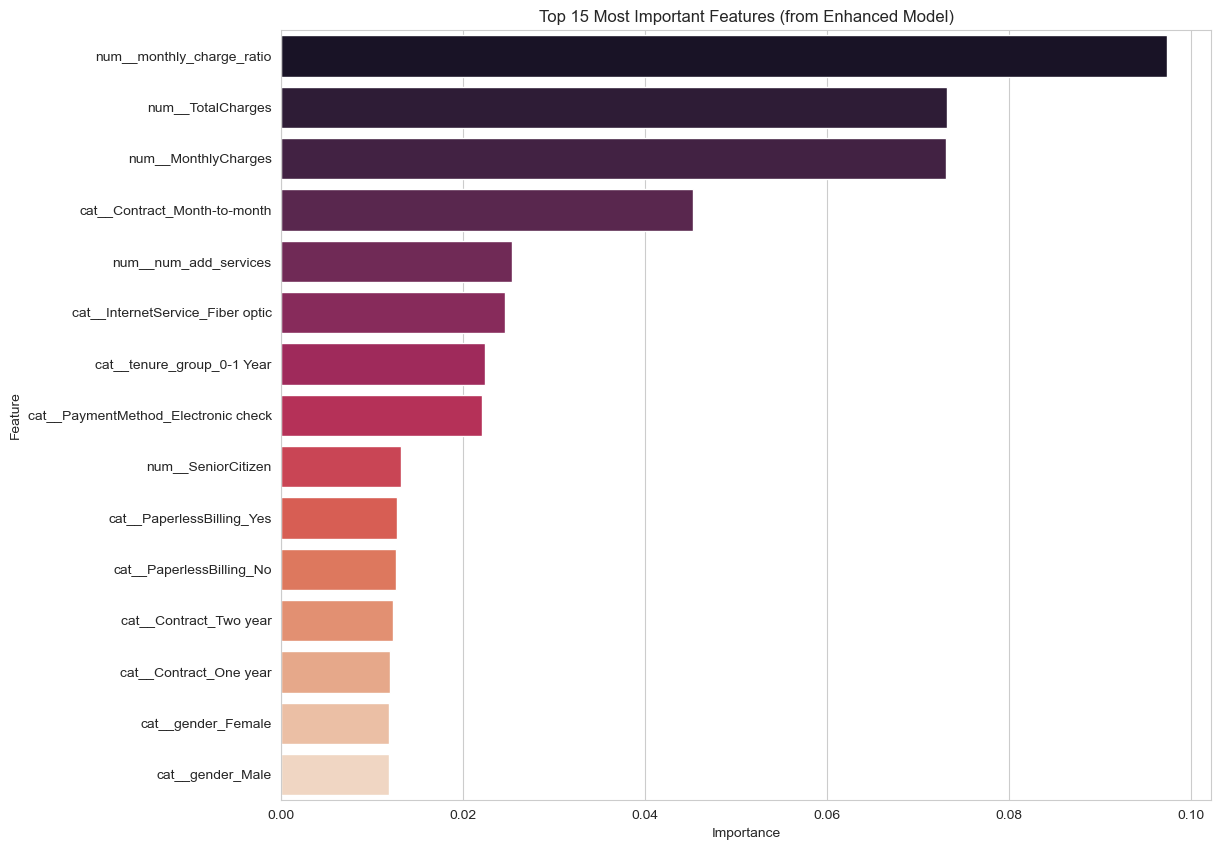

In [25]:
# To get feature importance, let's quickly train a RandomForest model with the engineered data
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor_eng),
                               ('classifier', RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train_eng, y_train_eng)

# Extract feature names after one-hot encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='rocket', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features (from Enhanced Model)')
plt.show()

### 项目阶段总结

项目前半部分展示了特征工程的实际价值：

1. 先用清洗后的原始特征建立基线模型；
2. 构造 `tenure_group`、`num_add_services`、`monthly_charge_ratio` 等客户行为特征；
3. 训练增强模型并与基线模型对比；
4. 使用随机森林的重要性分析观察哪些特征影响更大。

核心结论是：模型效果往往不仅取决于算法复杂度，更取决于特征是否表达了有用信息。

---

### 第 7 步：特征选择 - 精简特征集合

特征选择和特征工程不同：

- **特征工程** 是创造新特征；
- **特征选择** 是决定保留哪些特征。

特征选择可能带来这些好处：降低维度、提升解释性、减少训练时间、降低过拟合风险。但如果删掉了有用特征，也可能让模型表现变差。

本项目使用 `SelectFromModel`，并用随机森林作为基础模型，根据特征重要性筛选特征。

## 执行特征选择

在 pipeline 中使用 `SelectFromModel`，从工程化后的特征中保留更重要的一部分。

**思路说明：** 我们只在训练集上拟合预处理和特征选择步骤，然后再转换训练集和测试集。这样可以避免数据泄漏，同时也能观察特征选择后维度减少了多少。

In [26]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier to use as the base estimator for feature selection
rf_selector = RandomForestClassifier(random_state=42)

# Instantiate SelectFromModel
# Using 'median' as the threshold means features with importance greater than the median importance will be selected.
selector = SelectFromModel(estimator=rf_selector, threshold='median', prefit=False)

# Create a pipeline for feature selection
feature_selection_pipeline = Pipeline(steps=[('preprocessor', preprocessor_eng),
                                             ('selector', selector)])

# Fit the pipeline to the training data
feature_selection_pipeline.fit(X_train_eng, y_train_eng)

# Transform the training and testing data to get the selected features
X_train_selected = feature_selection_pipeline.transform(X_train_eng)
X_test_selected = feature_selection_pipeline.transform(X_test_eng)

# Print the shapes to compare
print(f"Original training data shape: {X_train_eng.shape}")
print(f"Selected training data shape: {X_train_selected.shape}")

Original training data shape: (5634, 22)
Selected training data shape: (5634, 2840)


## 使用筛选后的特征训练模型

完成特征选择后，再训练一个 Logistic Regression 模型，并与基线模型、增强模型进行对比。

**思路说明：** 这里继续保持建模方法一致，这样性能变化更容易归因于特征集合的变化。

In [28]:
# Create the full pipeline with the preprocessor and the classifier
selected_features_model = Pipeline(steps=[('preprocessor', preprocessor_eng),
                                         ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

# Train the model using the selected features
selected_features_model.fit(X_train_eng, y_train_eng)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**思路说明：** `classification_report` 会输出 precision、recall 和 F1-score。对于客户流失预测，尤其要关注流失类 `Churn = 1` 的指标。

In [29]:
# Predict on the test set with selected features
y_pred_selected = selected_features_model.predict(X_test_eng)

print("--- Model Performance (with Selected Features) ---")
print(classification_report(y_test_eng, y_pred_selected))

--- Model Performance (with Selected Features) ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## 比较模型表现

现在把三个模型的报告放在一起看，并汇总 Accuracy 和流失类 F1-score。

**思路说明：** 对比表可以帮助我们判断特征工程和特征选择是否真的改善了关键指标。

In [30]:
print("--- Baseline Model Performance ---")
print(classification_report(y_test_base, y_pred_base))

print("\n--- Enhanced Model Performance (with Feature Engineering) ---")
print(classification_report(y_test_eng, y_pred_eng))

print("\n--- Model Performance (with Selected Features) ---")
print(classification_report(y_test_eng, y_pred_selected))

# Summarize the performance metrics
print("\n--- Performance Summary ---")
print("Metric         | Baseline | Enhanced | Selected Features")
print("---------------|----------|----------|-------------------")
print(f"Accuracy       | {accuracy_score(y_test_base, y_pred_base):<8.2f} | {accuracy_score(y_test_eng, y_pred_eng):<8.2f} | {accuracy_score(y_test_eng, y_pred_selected):<8.2f}")

# Extract F1-score for class 1 (Churn) from classification reports
report_base = classification_report(y_test_base, y_pred_base, output_dict=True)
report_eng = classification_report(y_test_eng, y_pred_eng, output_dict=True)
report_selected = classification_report(y_test_eng, y_pred_selected, output_dict=True)

f1_churn_base = report_base['1']['f1-score']
f1_churn_eng = report_eng['1']['f1-score']
f1_churn_selected = report_selected['1']['f1-score']

print(f"F1-Score (Churn)| {f1_churn_base:<8.2f} | {f1_churn_eng:<8.2f} | {f1_churn_selected:<8.2f}")

--- Baseline Model Performance ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


--- Enhanced Model Performance (with Feature Engineering) ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409


--- Model Performance (with Selected Features) ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                    

## 讨论结果

### 第 8 步：讨论特征选择结果

特征选择并不一定自动提升性能。在这个 notebook 中，筛选特征后的模型可能和增强模型相近，甚至略差。

可能原因包括：

- `median` 阈值可能删掉了一些仍然有用的特征；
- 随机森林认为重要的特征，不一定最适合 Logistic Regression；
- One-hot 后的类别特征之间可能存在组合效果，简单阈值不一定能保留这种信息。

正确结论不是“特征选择没用”，而是：**特征选择需要作为实验过程进行调参和验证。**

### 总结：特征工程的力量与特征选择的权衡

本项目展示了两个互补能力：

- 特征工程让模型看到更有意义的信号；
- 特征选择尝试让输入空间更简洁。

一个合理的工作流通常是：

1. 清洗数据；
2. 建立基线模型；
3. 构造业务上有意义的新特征；
4. 对比模型指标；
5. 查看特征重要性；
6. 谨慎测试特征选择；
7. 如果需要，再尝试更强模型或超参数调优。

## 学生任务：进一步提升客户流失预测

请在当前 notebook 基础上继续改进模型，重点提升对流失客户的识别能力，尤其关注流失类的 F1-score。

建议方向：

1. **探索更多特征工程：** 例如合同类型、支付方式、服务组合、费用与留存时间之间的交互特征。
2. **尝试不同特征选择方法：** 例如 RFE、互信息、卡方检验，或调整 `SelectFromModel` 的阈值。
3. **评估更多模型：** 如 RandomForest、GradientBoosting、XGBoost、LightGBM、SVM 等。
4. **进行超参数调优：** 使用 `GridSearchCV` 或 `RandomizedSearchCV`。
5. **建立清晰对比：** 对比基线模型、增强模型、特征选择模型和你最终最佳模型。

### 提交标准

请提交一个完整的 `.ipynb` notebook，内容包括：

1. 所有代码、Markdown 解释、输出结果和可视化；
2. 你尝试过的特征工程和特征选择方法总结；
3. 各模型的关键指标，尤其是 Accuracy 和流失类 F1-score；
4. 一个清晰的模型表现对比表或图；
5. 对最重要特征的解释；
6. 你遇到的问题以及解决方式。